Elaboraremos un análisis sobre el comportamiento de los ingresos obtenidos por la venta de videojuegos a través de varios años, para tres diferentes regiones, diferentes plataformas, clasificaciones tanto de usuarios como de expertos y géneros.

Paso 1. Abrir el archivo de datos y estudio de la infomacion.

In [1]:
# Importamos las librerias
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats as st 

In [2]:
#Leemos le archivo
df_tienda=pd.read_csv('/datasets/games.csv')

In [3]:
df_tienda.info()
df_tienda.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


In [4]:
print(df_tienda.head(10))

                        Name Platform  Year_of_Release         Genre  \
0                 Wii Sports      Wii           2006.0        Sports   
1          Super Mario Bros.      NES           1985.0      Platform   
2             Mario Kart Wii      Wii           2008.0        Racing   
3          Wii Sports Resort      Wii           2009.0        Sports   
4   Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing   
5                     Tetris       GB           1989.0        Puzzle   
6      New Super Mario Bros.       DS           2006.0      Platform   
7                   Wii Play      Wii           2006.0          Misc   
8  New Super Mario Bros. Wii      Wii           2009.0      Platform   
9                  Duck Hunt      NES           1984.0       Shooter   

   NA_sales  EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     41.36     28.96      3.77         8.45          76.0          8      E  
1     29.08      3.58      6.81         0.77     

Paso 2. Prepara los datos

-.Cambiamos a minusculas los nombres de las columnas

In [5]:
#Asignamos los nuevos nombres
new_name_columns={'Name':'name','Platform':'platform','Year_of_Release':'year_of_release','Genre':'genre','NA_sales':'na_sales','EU_sales':'eu_sales','JP_sales':'jp_sales','Other_sales':'other_sales','Critic_Score':'critic_score','User_Score':'user_score','Rating':'rating'}
#Cambiamos los nombres 
df_tienda.rename(columns=new_name_columns,inplace=True)
#Imprimimos para comprobar el cambio
print(df_tienda.columns)
#Cambiamos a minusculas el contenido de las columnas
df_tienda['name']=df_tienda['name'].str.lower()
df_tienda['platform']=df_tienda['platform'].str.lower()
df_tienda['genre']=df_tienda['genre'].str.lower()
#print(df_tienda.head())
#df_tienda.info()

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


-.Encontramos datos ausentes, y reemplazamos los datos ausentes

In [6]:
#Encontramos y contamos los datos ausentes de la columna 'name'
#Contamos y encontramos los datos ausentes
print(df_tienda['name'].isna().sum())
print(df_tienda[df_tienda['name'].isna()])

#Rellenamos datos ausentes con la palabra 'unknonw'
df_tienda['name']=df_tienda['name'].fillna('unknown')
#Comprobamos que no existan datos nullos
print(df_tienda[df_tienda['name'].isna()])
print(df_tienda['name'].isna().sum())


2
      name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      gen           1993.0   NaN      1.78      0.53      0.00   
14244  NaN      gen           1993.0   NaN      0.00      0.00      0.03   

       other_sales  critic_score user_score rating  
659           0.08           NaN        NaN    NaN  
14244         0.00           NaN        NaN    NaN  
Empty DataFrame
Columns: [name, platform, year_of_release, genre, na_sales, eu_sales, jp_sales, other_sales, critic_score, user_score, rating]
Index: []
0


-.Encontramos y contamos los datos ausentes de la columna 'year_of_release'  

In [7]:
#Encontramos y contamos los datos ausentes de la columna 'year_of_release'  
print(df_tienda['year_of_release'].isna().sum())
#Rellenamos datos nulos con la mediana (elegi la mediana por que al ser una columna de años la media muestra decimales, ademas no existe mucha diferencian entre la media y la mediana de esta columna)
year_of_release_median=df_tienda['year_of_release'].median()
df_tienda['year_of_release']=df_tienda['year_of_release'].fillna(year_of_release_median)
#Comprobamos que no existan datos nullos
print(df_tienda['year_of_release'].isna().sum())
#Cambiamos el la columna 'year_of_releas' a entero
df_tienda['year_of_release'] = df_tienda['year_of_release'].astype(float)
df_tienda['year_of_release']=df_tienda['year_of_release'].astype(int)
#lo comverti a string para la etiqueta de mi grafico y no afecta el analisis
df_tienda['year_of_release']=df_tienda['year_of_release'].astype(str)


269
0


In [8]:
#Encontramos y contamos los datos ausentes de la columna 'genre'
#Contamos y encontramos los datos ausentes
print(df_tienda['genre'].isna().sum())
print(df_tienda[df_tienda['genre'].isna()])
#Rellenamos datos ausentes con la palabra 'unknonw'
df_tienda['genre']=df_tienda['genre'].fillna('other')
#Comprobamos que no existan datos nullos
print(df_tienda['genre'].isna().sum())


2
          name platform year_of_release genre  na_sales  eu_sales  jp_sales  \
659    unknown      gen            1993   NaN      1.78      0.53      0.00   
14244  unknown      gen            1993   NaN      0.00      0.00      0.03   

       other_sales  critic_score user_score rating  
659           0.08           NaN        NaN    NaN  
14244         0.00           NaN        NaN    NaN  
0


In [9]:
#Encontramos y contamos los datos ausentes de la columna 'critic_score'
#Contamos y encontramos los datos ausentes
print(df_tienda['critic_score'].isna().sum())
#Reemplazamos los valores con la media (considero no hay valores atípicos significativos)
critic_mean=df_tienda['critic_score'].mean()
df_tienda['critic_score']=df_tienda['critic_score'].fillna(critic_mean)
#Comprobamos datos nullos
print(df_tienda['critic_score'].isna().sum())

8578
0


In [10]:
#Encontramos y contamos los datos ausentes de la columna 'user_score'
#Contamos y encontramos los datos ausentes
print(df_tienda['user_score'].isna().sum())
#Convertimos el tipo de dato object/string a numerico
df_tienda['user_score']=pd.to_numeric(df_tienda['user_score'],errors='coerce') 
#Reemplazar los datos ausentes con la mediana debido a que existen muchos valores atipicos en esta columna
median_user_score=df_tienda['user_score'].median()
df_tienda['user_score']=df_tienda['user_score'].fillna(median_user_score)
#COnfirmamos que no hay ausentes
print(df_tienda['user_score'].isna().sum())

6701
0


In [11]:
#Encontramos y contamos los datos ausentes de la columna 'rating'
#Contamos y encontramos los datos ausentes
print(df_tienda['rating'].isna().sum())
#Rellenamos ausentes con 'TBD' ya que es una columna tipo string
df_tienda['rating'].fillna('TBD',inplace=True)
#Comprobamos que no haya valores ausentes

print(df_tienda['rating'].isna().sum())
#rating_mean=df_tienda['rating'].mean()
#print(df_tienda['rating'].head(25))


6766
0



-.Buscamos datos duplicados

In [12]:
print(df_tienda.duplicated().value_counts())

False    16715
dtype: int64


Obervamos que no existen datos duplicados

-.Calculamos la columna 'ventas_totales'

In [13]:
print(df_tienda.head())
df_tienda['total_sales']=df_tienda['na_sales']+df_tienda['eu_sales']+df_tienda['jp_sales']+df_tienda['other_sales']
print(df_tienda.head())


                       name platform year_of_release         genre  na_sales  \
0                wii sports      wii            2006        sports     41.36   
1         super mario bros.      nes            1985      platform     29.08   
2            mario kart wii      wii            2008        racing     15.68   
3         wii sports resort      wii            2009        sports     15.61   
4  pokemon red/pokemon blue       gb            1996  role-playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score  user_score rating  
0     28.96      3.77         8.45     76.000000         8.0      E  
1      3.58      6.81         0.77     68.967679         7.5    TBD  
2     12.76      3.79         3.29     82.000000         8.3      E  
3     10.93      3.28         2.95     80.000000         8.0      E  
4      8.89     10.22         1.00     68.967679         7.5    TBD  
                       name platform year_of_release         genre  na_sales  \
0                wi

Paso 3. Analiza los datos

In [14]:
#Juegos lanzados en diferentes años
df_tienda.groupby('year_of_release')['name'].count().sort_values(ascending=False).head(10)
# no todos los años son significativos pero muestro los 10 primeros

year_of_release
2007    1466
2008    1427
2009    1426
2010    1255
2011    1136
2006    1006
2005     939
2002     829
2003     775
2004     762
Name: name, dtype: int64

In [15]:
#Observa cómo varían las ventas de una plataforma a otra. 

Elegí las 10 plataformas con mayores ventas, tomando un periodo comprendido de 2011 a 2016, considero que este periodo representa una base más actualizada para realizar una proyección para el año 2017.

Ventas totales de las 10 plataformas mas vendidas 
  platform  total_sales
0      ps2      1255.77
1     x360       971.42
2      ps3       939.65
3      wii       907.51
4       ds       806.12
5       ps       730.86
6      gba       317.85
7      ps4       314.14
8      psp       294.05
9       pc       259.52


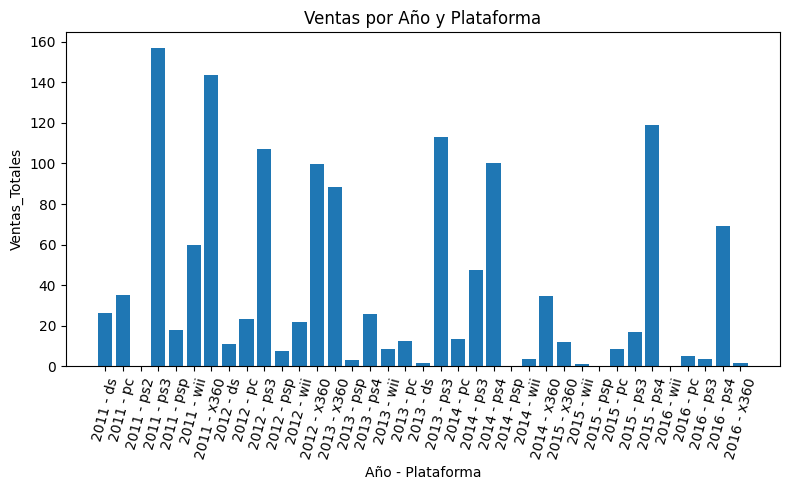

In [16]:
#Plataformas con mayores ventas totales
platform_top_sales=df_tienda.groupby('platform')['total_sales'].sum().sort_values(ascending=False).reset_index()
print('Ventas totales de las 10 plataformas mas vendidas ')
print(platform_top_sales.head(10))

#Las plataformas con mas ventas y filtramos para obtener solo esas plataformas
top_10_platform_sales=['ps2','x360','ps3','wii','ds','ps','gba','ps4','psp','pc']    
df_tienda_top_10= df_tienda[df_tienda['platform'].isin(top_10_platform_sales)]

#Filtramos y trabajamos con los ultimos 6 años, para descartara datos muy antigudos y para mejor presentacion de la grafica
year_gap=['2011','2012','2013','2014','2015','2016']
df_tienda_top_10_gap=df_tienda_top_10[df_tienda_top_10['year_of_release'].isin(year_gap)]

#Distribución basada en los datos de cada año.
df_tienda_top_10_years=df_tienda_top_10_gap.groupby(['year_of_release','platform'])['year_of_release','total_sales'].sum().sort_values(by='year_of_release',ascending=True).reset_index()
#print(df_tienda_top_10_years)
df_tienda_top_10_years['etiqueta'] =df_tienda_top_10_years['year_of_release'] + ' - ' +df_tienda_top_10_years['platform']
#Fotmato de la grafica
plt.figure(figsize=(8, 5))
plt.bar(df_tienda_top_10_years['etiqueta'], df_tienda_top_10_years['total_sales'])
plt.label='Ventas por Plataforma'
plt.xlabel('Año - Plataforma')
plt.ylabel('Ventas_Totales')
plt.title('Ventas por Año y Plataforma')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


year_of_release    2011    2012    2013    2014    2015   2016
platform                                                      
ds                26.18   11.01    1.54    0.00    0.00   0.00
pc                35.03   23.22   12.38   13.28    8.52   5.25
ps2                0.45    0.00    0.00    0.00    0.00   0.00
ps3              156.78  107.36  113.25   47.76   16.82   3.60
ps4                0.00    0.00   25.99  100.00  118.90  69.25
psp               17.82    7.69    3.14    0.24    0.12   0.00
wii               59.65   21.71    8.59    3.75    1.14   0.18
x360             143.84   99.74   88.58   34.74   11.96   1.52


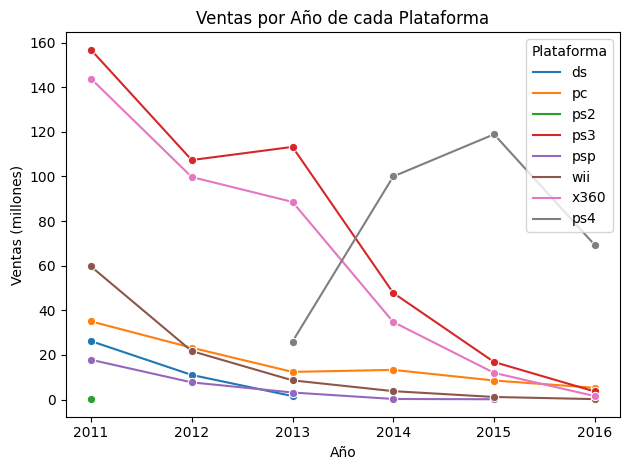

In [17]:
#Busca las plataformas que solían ser populares pero que ahora no tienen ventas.
tabla_pivot_1 = df_tienda_top_10_years.pivot_table(values='total_sales',index='platform',columns='year_of_release',aggfunc='sum',fill_value=0)
print(tabla_pivot_1)

#Formato grafica
sns.lineplot(data=df_tienda_top_10_years, x='year_of_release', y='total_sales', hue='platform', marker='o')
plt.title('Ventas por Año de cada Plataforma')
plt.label='Ventas por Plataforma'
plt.xlabel('Año')
plt.ylabel('Ventas (millones)')
plt.legend(title='Plataforma')
plt.grid(False)
plt.tight_layout()
plt.show()



Como resultado de mi análisis encontré, que las plataformas "gba y ps", en el periodo analizado no presentan ventas, pese a estar dentro de las 10 plataformas más vendidas del tiempo total comprendido en los datos. Las plataformas "ds, ps2 y psp" para el año 2016 no muestran ventas, la plataforma "ds" el años 2013 fue el último en el que registro ventas, de igual forma, la plataforma "ps2" desde el años 2011 no presentas ventas y la plataforma "psp" registro ventas descendientes desde 2011 culminando con cero ventas en 2016.
En 2011 las ventas de las plataformas "ps3 y x360" representaban los 2 primeros lugares en ventas totales, para años subsecuentes se observa una drástica disminución en sus ventas, para el año 2016 sus ventas son el 1%(x360) y 2%(ps3) respectivamente, en comparación con el año 2011. La plataforma "ps4" comienza con ventas de 25.99 millones en 2013 teniendo su pico de ventas en 2015 118.90 millones, con drástico descenso en 2016 del 50%.

In [18]:
#Ventas totales de los juegos por plataforma
total_sales_platform_game=df_tienda.groupby(['platform','name'])['total_sales'].sum()
print(total_sales_platform_game)

platform  name                      
2600      action force                  0.54
          adventure                     1.30
          adventures of tron            0.67
          air raid                      0.77
          air-sea battle                0.98
                                        ... 
xone      xcom 2                        0.04
          zombie army trilogy           0.11
          zombiu                        0.01
          zoo tycoon (2013)             0.36
          zumba fitness: world party    0.24
Name: total_sales, Length: 16710, dtype: float64


             sum      mean  petcentage
platform                              
ps4       314.14  0.801378   16.075861
x360      380.38  0.763815   19.465639
xone      159.32  0.645020    8.153072
ps3       445.57  0.629336   22.801685
wiiu       82.19  0.559116    4.206007
3ds       257.81  0.503535   13.193218
wii        95.02  0.482335    4.862572
pc         97.68  0.251105    4.998695
ds         38.73  0.210489    1.981976
psv        53.81  0.125431    2.753683
psp        29.01  0.092981    1.484563
ps2         0.45  0.064286    0.023028


<AxesSubplot:xlabel='platform', ylabel='total_sales'>

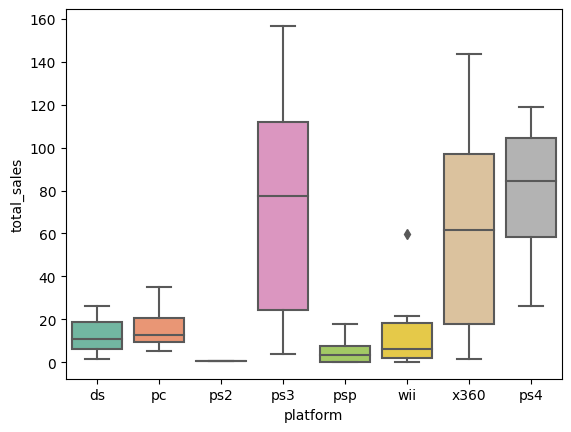

In [19]:
#Crea un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma
year_gap=['2011','2012','2013','2014','2015','2016']
df_games= df_tienda[df_tienda['year_of_release'].isin(year_gap)]

df_games_names=df_games.groupby(['name','platform'])['total_sales'].sum().reset_index()

#parametos de ventas por juegos desglosado por plataforma.
parametros_sales_games_platform=df_games.groupby('platform')['total_sales'].agg(['sum','mean']).sort_values(by='mean',ascending=False)
parametros_sales_games_platform['petcentage']=(parametros_sales_games_platform['sum']/(parametros_sales_games_platform['sum'].sum()))*100
print(parametros_sales_games_platform)

#Grafico de caja
sns.boxplot(data=df_tienda_top_10_years,x='platform',y='total_sales',palette='Set2')


La suma de las ventas de las plataformas "ps4, ps3 y x360" representan el 58.33 % del total de las ventas, las ventas promedio por juego de las tres plataformas mencionadas rondan valores muy similares, entre 0.80 y 0.64, de igual forma las ventas por videojuegos de las siguientes tres plataformas, muestran ventas promedios más distantes entre ellas "3ds" (0.50), "xone" (0.64) y "pc" (0.25); Las plataformas con menor ventas promedio por video juegos son "psp" (0.09) y "ps2" (0.06) además de presentan ventas totales muy bajas a comparación de las primeras tres plataformas.

In [20]:
#Mira cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular (tu elección).
#Elegi la plataforma "xbox360"
df_xbox_ventas=df_tienda[df_tienda['platform']=='x360'].reset_index()


Correlacion entre "Reseñas de lo usuarios vs Ventas totales"
0.058861507814542746


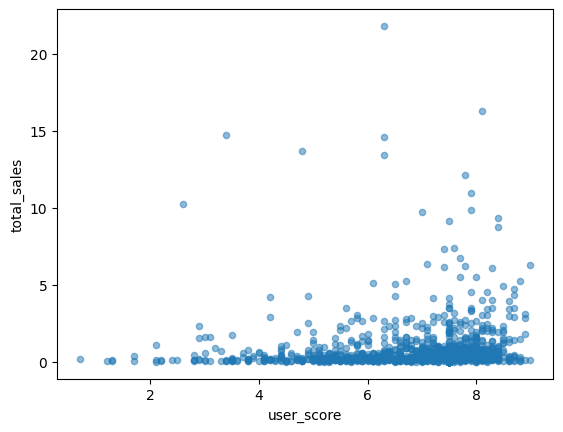

In [21]:
print('Correlacion entre "Reseñas de lo usuarios vs Ventas totales"')
print(df_xbox_ventas['user_score'].corr(df_xbox_ventas['total_sales']))
df_xbox_ventas.plot(x='user_score', y='total_sales',style='o',kind='scatter',alpha=0.5 )
plt.show()

Existe una pequeña relación positiva entre la calificación del usuario y los ingresos obtenidos de esta plataforma. 

Correlacion entre "Reseñas de lo expertos vs Ventas totales"
0.37489983252016695


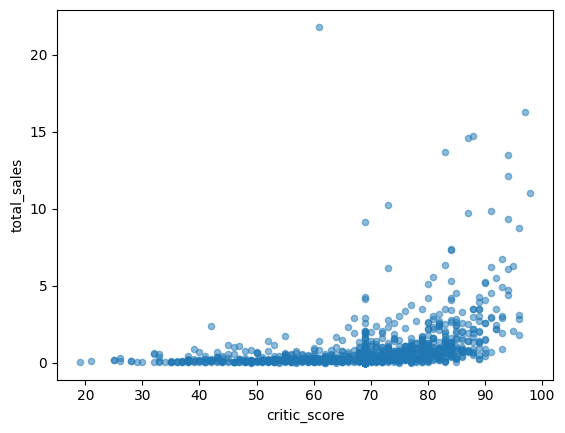

In [22]:
print('Correlacion entre "Reseñas de lo expertos vs Ventas totales"')
print(df_xbox_ventas['critic_score'].corr(df_xbox_ventas['total_sales']))
df_xbox_ventas.plot(x='critic_score', y='total_sales',style='o',kind='scatter',alpha=0.5 )
plt.show()

Existe una relación positiva de mayor medida entre la calificación de los expertos y los ingresos obtenidos de esta plataforma.

2418
platform                      3ds    ds    pc  ps2   ps3   ps4  psp   psv  \
name                                                                        
 beyblade burst              0.03  0.00  0.00  0.0  0.00  0.00  0.0  0.00   
 fire emblem fates           1.67  0.00  0.00  0.0  0.00  0.00  0.0  0.00   
 frozen: olaf's quest        0.59  0.51  0.00  0.0  0.00  0.00  0.0  0.00   
 haikyu!! cross team match!  0.04  0.00  0.00  0.0  0.00  0.00  0.0  0.00   
 tales of xillia 2           0.00  0.00  0.00  0.0  0.84  0.00  0.0  0.00   
...                           ...   ...   ...  ...   ...   ...  ...   ...   
alan wake                    0.00  0.00  0.07  0.0  0.00  0.00  0.0  0.00   
alia's carnival! sacrament   0.00  0.00  0.00  0.0  0.00  0.00  0.0  0.03   
alice: madness returns       0.00  0.00  0.12  0.0  0.58  0.00  0.0  0.00   
alien breed trilogy          0.00  0.00  0.00  0.0  0.00  0.00  0.0  0.00   
alien: isolation             0.00  0.00  0.15  0.0  0.33  1.12  0.0  0.

<AxesSubplot:xlabel='platform', ylabel='total_sales'>

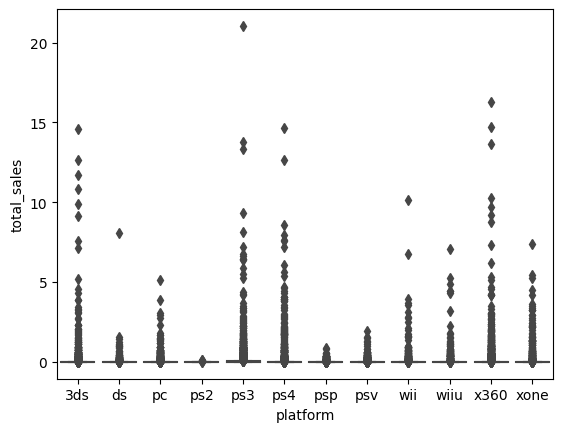

In [23]:
#Teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataformas.
print(df_games['name'].nunique())
pivot_table_games = pd.pivot_table(
    data=df_games,
    values='total_sales',
    index='name',
    columns='platform',
    aggfunc=sum,  # or 'sum', 'count', 'median', or a list of functions
    fill_value=0,     # Optional: value to replace NaN with
)
print(pivot_table_games.head(75))
melted_data = pivot_table_games.melt(var_name='platform', value_name='total_sales')
sns.boxplot(data=melted_data, x='platform', y='total_sales')

Nota: Al ser más de 2,000 juegos diferentes es complejo elaborar un análisis más detallado, pero como se muestra en la tabla dinámica anterior, existen muchos juegos con ventas en algunas plataformas y en otras no, como "alien: isolation", con ventas en pc, ps3, ps4, xone, etc. pero no en psp o pvs, esto puede depender del productor de juego y la compatibilidad con la plataforma.

           genre  name  total_sales
0         action  1269       557.80
1        shooter   329       402.91
2   role-playing   465       245.63
3         sports   389       237.15
4           misc   375       139.42
5       platform   122        88.68
6         racing   180        88.31
7       fighting   159        66.90
8     simulation   136        50.26
9      adventure   410        45.04
10      strategy   117        22.16
11        puzzle    71         9.85
              name  total_sales
count    12.000000    12.000000
mean    335.166667   162.842500
std     324.264716   169.640923
min      71.000000     9.850000
25%     132.500000    48.955000
50%     254.500000    88.495000
75%     394.250000   239.270000
max    1269.000000   557.800000


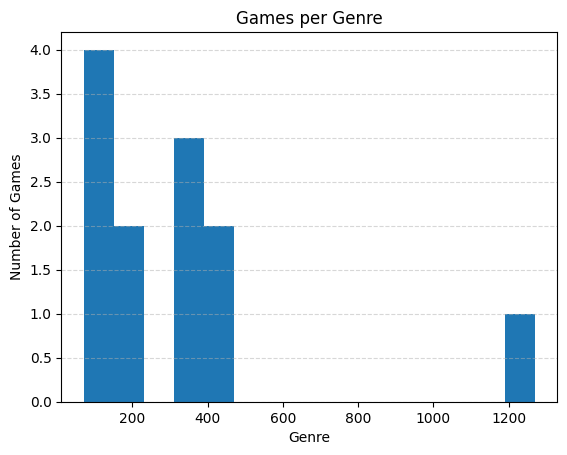

In [26]:
#Echa un vistazo a la distribución general de los juegos por género. 
#¿Qué se puede decir de los géneros más rentables? ¿Puedes generalizar acerca de los géneros con ventas altas y bajas?
df_games_genre=df_games.groupby('genre')['name','total_sales'].agg({'name':'count','total_sales':'sum'}).sort_values(by='total_sales',ascending=False).reset_index()
print(df_games_genre.head(50))
print(df_games_genre.describe())

df_games_genre.hist(column='name',bins=15,grid=False)
plt.xlabel('Genre')
plt.ylabel('Number of Games')
plt.title('Games per Genre')
plt.grid(axis='y', linestyle='--', alpha=0.5)
#plt.tight_layout()
plt.show()

Tenemos una distribución negativa ya que los datos estan sesgados a la izquierda, es unimodal en 180, tenemos una barra que representa valores atípicos en este caso 1269.
El género "action" cuenta con 1,269 juegos ventas totales de 557.80 millones siendo el primero en la lista, muy por arriba del segundo género "shooter" en la cantidad de juegos 329 pero con ventas totales muy cercanas 402.91 millones. 
Considero que los juegos que producen más adrenalina al usuario representan los primeros lugares en ventas totales mientras que los juegos que requieren un nivel de concentración más alto se encuentran en los últimos lugares en ventas totales. 

Paso 4. Crea un perfil de usuario para cada región

In [27]:
#Las cinco plataformas principales.
print('Las cinco plataformas principales para cada region')
print()
print('Region América del Norte')
df_NA_top_5_platform=df_games.groupby('platform')['na_sales'].sum().reset_index()
print(df_NA_top_5_platform.head(5).sort_values(by='na_sales',ascending=False))
print()
print('Union Europea')
df_UE_top_5_platform=df_games.groupby('platform')['eu_sales'].sum().reset_index()
print(df_UE_top_5_platform.head(5).sort_values(by='eu_sales',ascending=False))
print()
print('Japón ')
df_UE_top_5_platform=df_games.groupby('platform')['jp_sales'].sum().reset_index()
print(df_UE_top_5_platform.head(5).sort_values(by='jp_sales',ascending=False))


Las cinco plataformas principales para cada region

Region América del Norte
  platform  na_sales
4      ps3    168.26
0      3ds     82.65
2       pc     29.88
1       ds     18.86
3      ps2      0.13

Union Europea
  platform  eu_sales
4      ps3    163.10
0      3ds     61.27
2       pc     56.70
1       ds      9.24
3      ps2      0.13

Japón 
  platform  jp_sales
0      3ds    100.62
4      ps3     49.39
1       ds      8.04
3      ps2      0.09
2       pc      0.00


Podemos apreciar que las plataforma "ps3" y "3ds" en las tres regiones se encuentra entre las mas populares, con ventas promedio de 126.92 millones para "ps3" y 81.51 milloes para "3ds", de igual forma podemos resaltar que la plataforma "pc" que representa el tercer lugar de ventas en las regiones de "América del Norte" y "Union Europea" no tiene ventas en la region "Japón".

In [28]:
#Los cinco géneros principales. Explica la diferencia.
print('Las cinco Géneros principales para cada region')
print()
print('Region América del Norte')
df_NA_top_5_platform=df_games.groupby('genre')['na_sales'].sum().reset_index()
print(df_NA_top_5_platform.head(5).sort_values(by='na_sales',ascending=False))
print()
print('Union Europea')
df_UE_top_5_platform=df_games.groupby('genre')['eu_sales'].sum().reset_index()
print(df_UE_top_5_platform.head(5).sort_values(by='eu_sales',ascending=False))
print()
print('Japón ')
df_UE_top_5_platform=df_games.groupby('genre')['jp_sales'].sum().reset_index()
print(df_UE_top_5_platform.head(5).sort_values(by='jp_sales',ascending=False))

Las cinco Géneros principales para cada region

Region América del Norte
       genre  na_sales
0     action    230.92
3       misc     69.69
4   platform     38.28
2   fighting     31.63
1  adventure     14.76

Union Europea
       genre  eu_sales
0     action    199.12
3       misc     39.72
4   platform     30.07
2   fighting     16.24
1  adventure     13.96

Japón 
       genre  jp_sales
0     action     63.62
3       misc     17.60
2   fighting     12.38
4   platform     12.13
1  adventure     12.07


Los géneros más vendidos por región muestran la misma tendencia, destacando el género "action" que representa más de tres veces las ventas del siguiente en la lista el cual es "misc".

In [29]:
#Si las clasificaciones de ESRB afectan a las ventas en regiones individuales.
print()
print('Ventas por Clasificacion ESRB por region')
print()
print("Region América del Norte")
df_region_sales_rating_NA=df_games.groupby('rating')['na_sales'].sum().sort_values(ascending=False).reset_index()
print(df_region_sales_rating_NA.head(50))
print()
print("Region Union Europea")
df_region_sales_rating_EU=df_games.groupby('rating')['eu_sales'].sum().sort_values(ascending=False).reset_index()
print(df_region_sales_rating_EU.head(50))
print()
print("Region Japon")
df_region_sales_rating_JP=df_games.groupby('rating')['jp_sales'].sum().sort_values(ascending=False).reset_index()
print(df_region_sales_rating_JP.head(50))


Ventas por Clasificacion ESRB por region

Region América del Norte
  rating  na_sales
0      M    308.45
1      E    170.17
2    TBD    123.69
3   E10+    117.72
4      T    109.31
5     EC      0.42
6     RP      0.00

Region Union Europea
  rating  eu_sales
0      M    250.26
1      E    141.73
2    TBD    116.61
3      T     83.16
4   E10+     78.00
5     RP      0.03
6     EC      0.00

Region Japon
  rating  jp_sales
0    TBD    138.21
1      E     36.68
2      T     33.39
3      M     26.14
4   E10+     11.23
5     EC      0.00
6     RP      0.00


Como resultado del análisis, los juegos clasificación "M" en las regiones "América del Norte" y "Unión Europea", representa el número uno en ventas, los juegos con la clasificación "E", en las tres regiones representan el segundo lugar en ventas; En la región "Japón" observamos que existen juegos a la que no se les fue asignada o no se les pudieron asignar clasificación dentro de estos parámetros.

Paso 5. Prueba las siguientes hipótesis:

In [30]:
#Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

In [31]:
print('h0=La calificacion promedio de los usuarios es diferente para las platafomars Xbox One y PC.')
print('h1=La calificacion promedio de los usuarios es igual para las platafomars Xbox One y PC.')

#Calculamos la media del la calificacion de los usuarios para la plataforma Xbox One.
df_xone=df_games[df_games['platform']=='xone']
mean_user_score_xone=df_xone.groupby('platform')['user_score'].mean()
print(mean_user_score_xone)

#Calculamos la media del la calificacion de los usuarios para la plataforma PC.
df_pc=df_games[df_games['platform']=='pc']
mean_user_score_pc=df_pc.groupby('platform')['user_score'].mean()
print(mean_user_score_pc)

   
# si el valor p es menor que alpha, rechazamos la hipótesis

alpha = 0.05  # el nivel de significancia estadística crítica

results = st.ttest_ind(df_xone['user_score'], df_pc['user_score'], equal_var=False) # realizar una prueba

print('valor p: ', results.pvalue) # extraer el valor p

if results.pvalue < alpha: # comparar el valor p con el umbral
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")    

h0=La calificacion promedio de los usuarios es diferente para las platafomars Xbox One y PC.
h1=La calificacion promedio de los usuarios es igual para las platafomars Xbox One y PC.
platform
xone    6.778947
Name: user_score, dtype: float64
platform
pc    6.672751
Name: user_score, dtype: float64
valor p:  0.3361293822803634
No podemos rechazar la hipótesis nula


Elegimos hipótesis de una cola ya que este método es idóneo para comparar la media de dos poblaciones. Podemos observar que la hipótesis nula no se rechaza ya que la probabilidad de que las medias de estas dos poblaciones sean diferentes es mayor a mi parámetro alpha, que es 0.05 elegir este parámetro porque es más restrictivo.

In [32]:
#Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

In [33]:
print('h0=La calificacion promedio de los usuarios es igual para los generos Accion y Deporte.')
print('h1=La calificacion promedio de los usuarios es diferente para los generos Accion y Deporte.')

#Calculamos la media del la calificacion de los usuarios para la plataforma Xbox One.
df_action=df_games[df_games['genre']=='action']
mean_user_score_action=df_action.groupby('genre')['user_score'].mean()
print(mean_user_score_action)

#Calculamos la media del la calificacion de los usuarios para la plataforma PC.
df_sports=df_games[df_games['genre']=='sports']
mean_user_score_sports=df_sports.groupby('genre')['user_score'].mean()
print(mean_user_score_sports)

   
# si el valor p es menor que alpha, rechazamos la hipótesis

alpha = 0.05  # el nivel de significancia estadística crítica

results = st.ttest_ind(df_action['user_score'], df_sports['user_score'], equal_var=False) # realizar una prueba

print('valor p: ', results.pvalue) # extraer el valor p

if results.pvalue < alpha: # comparar el valor p con el umbral
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")   

h0=La calificacion promedio de los usuarios es igual para los generos Accion y Deporte.
h1=La calificacion promedio de los usuarios es diferente para los generos Accion y Deporte.
genre
action    7.121119
Name: user_score, dtype: float64
genre
sports    6.330591
Name: user_score, dtype: float64
valor p:  2.6364667922335543e-18
Rechazamos la hipótesis nula


Elegimos hipótesis de una cola ya que este método es idóneo para comparar la media de dos poblaciones. Podemos observar que la hipótesis nula se rechaza ya que la probabilidad de que las medias de estas dos poblaciones sean diferentes es mayor a mi parámetros alpha, que es 0.05 elegí este parámetro porque es más restrictivo.

Paso 6. Escribe una conclusión general.

Se realizo un análisis sobre los ingresos obtenidos por venta de videojuegos, para el periodo comprendido entre 2011 y 2016, de lo cual obtuvimos que las plataformas, PS4, PS3 y X360 concentran más de la mitad de las ventas totales, con ventas totales muy similares, sin embargo, podemos observar una caída abrupta en ventas de PS3 y X360 entre 2011 y 2016 evidencia el ciclo de vida natural de las consolas. De igual forma los géneros Action y Shooter liderean el sector ya que de estos dos géneros se obtiene la mayoría de los ingresos. Los Juegos con clasificaciones E y M son los mas adquiridos por los usuarios en las regiones América del norte y Unión Europea, en relación con la región Japón destaca la existencia de juegos con calificación no determinada. El análisis estadístico confirma que, aunque existe una relación positiva entre calificaciones (especialmente de expertos) y ventas, no siempre se alcanza significancia estadística. La distribución de los datos es negativa y sesgada, con presencia de valores atípicos que deben considerarse en futuras proyecciones.